# Bitcoin Prophet Comparator and Deferred Model Registry

## Role
This notebook has two purposes: (1) evaluate Prophet as an additional non-neural comparator under the project's Bitcoin forecasting protocol, and (2) document model families that were considered during project development but not included in the final empirical evidence.

## Inputs
The canonical Bitcoin daily target (same pipeline as Notebooks 01-04) and the frozen Prophet forecast column (`Prophet_Periodic_Refit`) in `results/validated_forecasts.csv`, together with the standalone point vector `results/prophet_rolling_forecast.csv`.

## Outputs
Artifact-derived Prophet diagnostics and a deferred/unavailable model scope registry only. This notebook does not create or overwrite any authoritative forecast vector.

## Depends On
`01_Bitcoin_Data_EDA.ipynb`
`02_Bitcoin_Classical_Baselines.ipynb`

## Authoritative Status
`SUPPORTING COMPARATOR + SCOPE TRANSPARENCY`

## What This Notebook Does Not Do
It does not evaluate foundation models, compute Trust Scores, calculate final statistical inference, run cross-domain comparisons, or assign empirical performance to any unavailable or deferred model.

# 1. Objective and Research Questions

### Q1 — Prophet

> Does a periodic-refit Prophet forecasting system provide competitive Bitcoin one-step performance relative to the transparent classical floor established in Notebook 02?

### Q2 — Evaluation Scope

> Which additional model families were considered but not executed for the authoritative evidence set, and what technical or methodological constraints explain their exclusion?

The second question is about **scope transparency**, not performance. Models in the registry (Section 7) are not described as having failed unless they were actually executed and produced a documented result -- most were never run at all, for documented environment or dependency reasons.

# 2. Setup

Standard project-root discovery and the repository's existing Bitcoin pipeline utilities. No data-loading or metric logic is duplicated here, and no packages are installed by this notebook.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.bitcoin_pipeline import *

RUN_GENERATION = False
PROMOTE_TO_AUTHORITATIVE = False
RUN_PROPHET_GENERATION = False  # Safety flag: this notebook is artifact-driven and does not refit Prophet.

# 3. Prophet Model

In [2]:
# Load once: canonical target/split and the frozen validated forecast vectors.
_, target = load_bitcoin_target(ROOT)
train, test = canonical_split(target)
validated = load_validated_forecasts(ROOT)
forecasts = forecast_series(validated, target)
validated[['Actual', 'Prophet_Periodic_Refit']].tail()

,Actual,Prophet_Periodic_Refit
Timestamp,,
2026-07-03 00:00:00+00:00,62522.46,55731.105091
2026-07-04 00:00:00+00:00,63086.18,55266.985354
2026-07-05 00:00:00+00:00,63587.06,54802.865616
2026-07-06 00:00:00+00:00,64000.10,54338.745879
2026-07-07 00:00:00+00:00,63902.77,53874.626142


## 3.1 Refit Protocol

Verified directly from `src.bitcoin_advanced_models.periodic_refit_prophet_forecast`: at each test position, if no model exists yet or `position % 30 == 0`, Prophet is refit on the 128 daily prices strictly before that date; every prediction (whether at a refit position or not) is generated from the currently held model. Between scheduled refits, the held model is **not** updated with newly revealed actuals at all -- it simply continues producing predictions from its last fit until the next scheduled refit position.

In [3]:
protocol_table = pd.DataFrame({
    'Value': [
        '128 strictly prior daily prices',
        'Every 30 forecast dates (position % 30 == 0)',
        '1 day',
        len(test),
        'Held model from the last refit continues predicting; no incremental update',
        'No',
        'No -- newly revealed actuals only enter the model at the next scheduled refit, not immediately',
    ],
}, index=[
    'Historical fitting window', 'Refit cadence', 'Forecast horizon', 'Test targets',
    'Update inside 30-day block', 'Uses target t?', 'Uses observations revealed after previous forecasts?',
])
protocol_table

,Value
Historical fitting window,128 strictly prior daily prices
Refit cadence,Every 30 forecast dates (position % 30 == 0)
Forecast horizon,1 day
Test targets,1061
Update inside 30-day block,Held model from the last refit continues predi...
Uses target t?,No
Uses observations revealed after previous forecasts?,No -- newly revealed actuals only enter the mo...


Prophet's operational update schedule differs materially from the daily-updated classical systems in Notebook 02 (Naive, SES, additive-trend smoothing, and ARIMA all incorporate the previous day's actual before the next forecast). Prophet is therefore described as **past-only periodic-refit one-step forecasting**, not identical rolling one-step forecasting -- it is still leakage-free, but not operationally equivalent to the daily-updated comparators.

## 3.2 Prophet Model Configuration

Every explicitly-set argument below is read directly from `src.bitcoin_advanced_models.periodic_refit_prophet_forecast`. Every unset field is read live from an unfit `Prophet(...)` object constructed with the exact same arguments used by the generation code -- this only inspects constructor attributes; it does not fit or forecast anything.

In [4]:
from prophet import Prophet
import prophet as _prophet_pkg

_inspection_model = Prophet(
    daily_seasonality=False,
    weekly_seasonality=False,
    yearly_seasonality=False,
    seasonality_mode='additive',
    uncertainty_samples=0,
)

configuration_table = pd.DataFrame({
    'Value': [
        f'prophet=={_prophet_pkg.__version__}',
        _inspection_model.growth,
        _inspection_model.seasonality_mode,
        _inspection_model.daily_seasonality,
        _inspection_model.weekly_seasonality,
        _inspection_model.yearly_seasonality,
        'None (no add_seasonality calls in the generation code)',
        _inspection_model.holidays,
        _inspection_model.changepoint_prior_scale,
        _inspection_model.seasonality_prior_scale,
        _inspection_model.holidays_prior_scale,
        _inspection_model.n_changepoints,
        _inspection_model.changepoint_range,
        f'{_inspection_model.interval_width} (framework default; moot for output because uncertainty_samples=0 disables interval computation)',
        _inspection_model.uncertainty_samples,
        _inspection_model.mcmc_samples,
        'None (no add_country_holidays call in the generation code)',
        'None',
        'CmdStanPy (MAP / L-BFGS optimisation, since mcmc_samples=0)',
        'Not explicitly configured in the project implementation -- Prophet exposes no seed/random_state constructor argument for MAP estimation',
    ],
}, index=[
    'Prophet package/version', 'Growth', 'Seasonality mode', 'Daily seasonality', 'Weekly seasonality',
    'Yearly seasonality', 'Additional seasonalities', 'Holidays', 'Changepoint prior scale',
    'Seasonality prior scale', 'Holidays prior scale', 'Number of changepoints', 'Changepoint range',
    'Interval width', 'Uncertainty samples', 'MCMC samples', 'Country holidays', 'Custom regressors',
    'Stan/backend', 'Seed / random state',
])
configuration_table

E:\Re_Sc_AM\TimeSeriesFoundationModels\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


,Value
Prophet package/version,prophet==1.3.0
Growth,linear
Seasonality mode,additive
Daily seasonality,False
Weekly seasonality,False
Yearly seasonality,False
Additional seasonalities,None (no add_seasonality calls in the generati...
Holidays,None
Changepoint prior scale,0.05
Seasonality prior scale,10.0


`daily_seasonality`, `weekly_seasonality`, `yearly_seasonality`, `seasonality_mode`, and `uncertainty_samples` are explicit constructor arguments in the generation code. Every other row is a Prophet framework default for this exact installed version, read live above rather than assumed from memory.

## 3.3 Reproducibility Record

Prophet fitting may involve backend-specific numerical behaviour, and no explicit seed or independent rerun test exists in this repository for the Prophet path (unlike the PE-LSTM and PE-Transformer, which both have a documented three-fresh-kernel-run check -- Notebooks 03 and 04). Bit-level determinism is therefore not claimed here.

In [5]:
reproducibility_record = pd.DataFrame({
    'Evidence': [
        'Prophet',
        _prophet_pkg.__version__,
        'CmdStanPy (MAP / L-BFGS optimisation)',
        'Recorded historically as Windows x86-64 (docs/bitcoin_reproducibility.md)',
        'CPU-only',
        'No',
        'No -- not independently tested',
        'No',
        'Yes',
        'Yes',
        'Partial -- the generation function is present and preserved, but full end-to-end regeneration was not re-executed or re-verified in this notebook',
    ],
}, index=[
    'Framework', 'Version', 'Backend', 'Platform', 'CPU/GPU', 'Explicit random seed set',
    'Deterministic execution verified', 'Independent reruns preserved', 'Frozen forecast vector preserved',
    'Forecast artifact SHA-256 protected', 'Full model regeneration currently reproducible',
])
reproducibility_record

,Evidence
Framework,Prophet
Version,1.3.0
Backend,CmdStanPy (MAP / L-BFGS optimisation)
Platform,Recorded historically as Windows x86-64 (docs/...
CPU/GPU,CPU-only
Explicit random seed set,No
Deterministic execution verified,No -- not independently tested
Independent reruns preserved,No
Frozen forecast vector preserved,Yes
Forecast artifact SHA-256 protected,Yes


> Prophet reproducibility is supported at the frozen-artifact level; exact bit-level refit reproducibility has not been independently demonstrated.

# 4. Prophet Results

## 4.1 Forecast Performance

In [6]:
prophet_metrics = metric_table(
    validated.Actual,
    {'Prophet — 30-Day Periodic Refit': validated.Prophet_Periodic_Refit},
    train,
)
prophet_metrics.round(3)

,MAE,RMSE,MAPE,sMAPE,MASE,N
Model,,,,,,
Prophet — 30-Day Periodic Refit,8195.263,10781.163,11.2,11.287,29.061,1061


Recomputed here from the frozen `results/validated_forecasts.csv` `Prophet_Periodic_Refit` column via the repository's canonical `metric_table` function, not hard-coded.

## 4.2 Context Against the Classical Floor

Naive and Simple Exponential Smoothing (Notebook 02's strongest non-Naive classical model by RMSE) provide local context for Prophet's raw error numbers.

In [7]:
context_names = ['Naive', 'Simple Exponential Smoothing — Rolling One-Step', 'Prophet — 30-Day Periodic Refit']
context_table = metric_table(validated.Actual, {n: forecasts[n] for n in context_names}, train)
context_table['Relative RMSE vs Naive'] = context_table['RMSE'] / context_table.loc['Naive', 'RMSE']
context_table['% MAE degradation vs Naive'] = 100 * (context_table['MAE'] / context_table.loc['Naive', 'MAE'] - 1)
context_table['% RMSE degradation vs Naive'] = 100 * (context_table['RMSE'] / context_table.loc['Naive', 'RMSE'] - 1)
context_table[['MAE', 'RMSE', 'Relative MAE vs Naive', 'Relative RMSE vs Naive',
               '% MAE degradation vs Naive', '% RMSE degradation vs Naive']].round(3)

,MAE,RMSE,Relative MAE vs Naive,Relative RMSE vs Naive,% MAE degradation vs Naive,% RMSE degradation vs Naive
Model,,,,,,
Naive,1290.353,1853.625,1.000,1.000,0.000,0.000
Simple Exponential Smoothing — Rolling One-Step,1290.359,1855.731,1.000,1.001,0.000,0.114
Prophet — 30-Day Periodic Refit,8195.263,10781.163,6.351,5.816,535.118,481.626


Prophet's observed MAE is approximately 535% higher than Naive's, and its RMSE is approximately 482% higher (exact values in the table above) -- an order-of-magnitude gap, not a marginal ranking difference. No statistical-significance claim is made here; that determination belongs to `11_Bitcoin_Statistical_Inference.ipynb`.

## 4.3 Forecast vs Actual

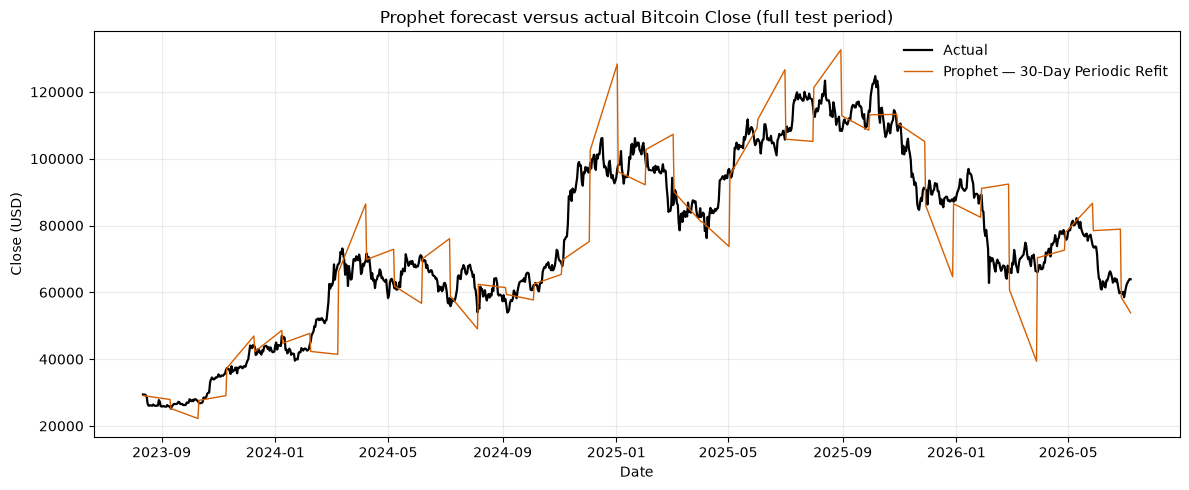

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(validated.index, validated.Actual, color='black', linewidth=1.6, label='Actual')
ax.plot(validated.index, validated.Prophet_Periodic_Refit, color='#D55E00', linewidth=1.0, label='Prophet — 30-Day Periodic Refit')
ax.set(title='Prophet forecast versus actual Bitcoin Close (full test period)', xlabel='Date', ylabel='Close (USD)')
ax.grid(alpha=0.25)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

## 4.4 Residual Analysis

Residuals are defined consistently as `e_t = y_t - y_hat_t` (Actual minus Forecast).

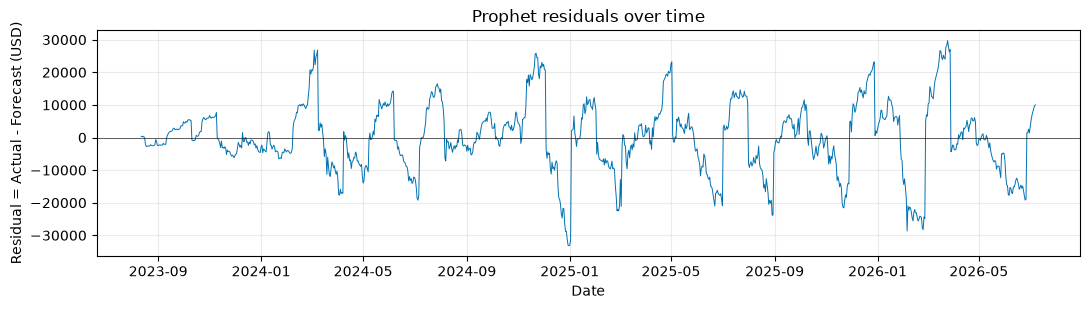

In [9]:
residual = validated.Actual - validated.Prophet_Periodic_Refit

fig, ax = plt.subplots(figsize=(11, 3.2))
ax.plot(residual.index, residual, color='#0072B2', linewidth=0.7)
ax.axhline(0, color='black', linewidth=0.7, alpha=0.6)
ax.set(title='Prophet residuals over time', xlabel='Date', ylabel='Residual = Actual - Forecast (USD)')
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

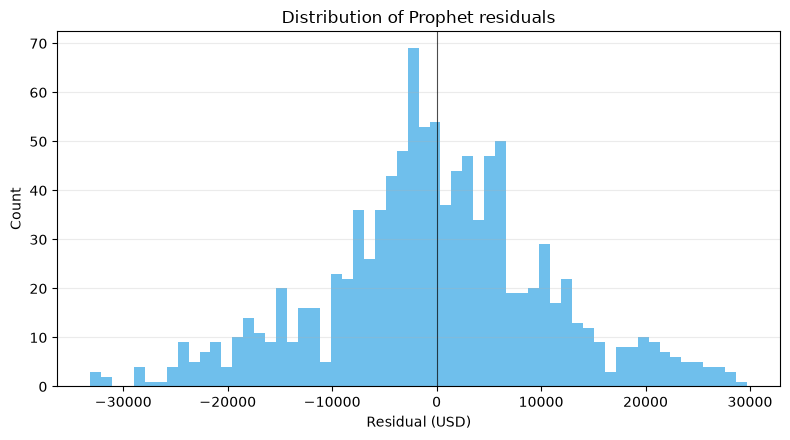

In [10]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(residual, bins=60, color='#56B4E9', alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8, alpha=0.7)
ax.set(title='Distribution of Prophet residuals', xlabel='Residual (USD)', ylabel='Count')
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()
plt.show()

In [11]:
residual_summary = pd.Series({
    'Mean': residual.mean(), 'Median': residual.median(), 'Std Dev': residual.std(),
    'Min': residual.min(), 'Max': residual.max(),
}, name='Prophet — 30-Day Periodic Refit').to_frame().T.round(3)
residual_summary

,Mean,Median,Std Dev,Min,Max
Prophet — 30-Day Periodic Refit,-179.268,-467.485,10784.756,-33179.696,29729.265


The residual mean (approximately -\$179) is close to zero relative to the huge dispersion (std approximately \$10,785), but the median (approximately -\$467) is more negative, and both are dwarfed by the extremes (min approximately -\$33,180, max approximately +\$29,729) -- Prophet does not show a simple one-directional bias so much as very large, roughly symmetric misses in both directions during rapid price movement, consistent with a stale periodic-refit model failing to track a fast-moving series. No causal claim is made about which specific price moves triggered which errors.

## 4.5 Error Across the 30-Day Refit Cycle

This diagnostic is derived entirely from the existing frozen forecast and the known refit schedule (`position % 30`, matching the generation code's own loop index) -- Prophet is not rerun here.

In [12]:
position = np.arange(len(validated))
cycle_position = position % 30
abs_error = (validated.Actual - validated.Prophet_Periodic_Refit).abs()

cycle_bins = pd.cut(
    cycle_position,
    bins=[-1, 4, 9, 14, 19, 24, 29],
    labels=['0-4', '5-9', '10-14', '15-19', '20-24', '25-29'],
)
refit_cycle_mae = (
    pd.DataFrame({'Bin': cycle_bins, 'Absolute Error': abs_error.to_numpy()})
    .groupby('Bin', observed=True)['Absolute Error']
    .agg(MAE='mean', N='count')
)
refit_cycle_mae.round(3)

,MAE,N
Bin,,
0-4,3211.543,180
5-9,5903.072,180
10-14,7295.853,176
15-19,9610.552,175
20-24,11293.390,175
25-29,12070.189,175


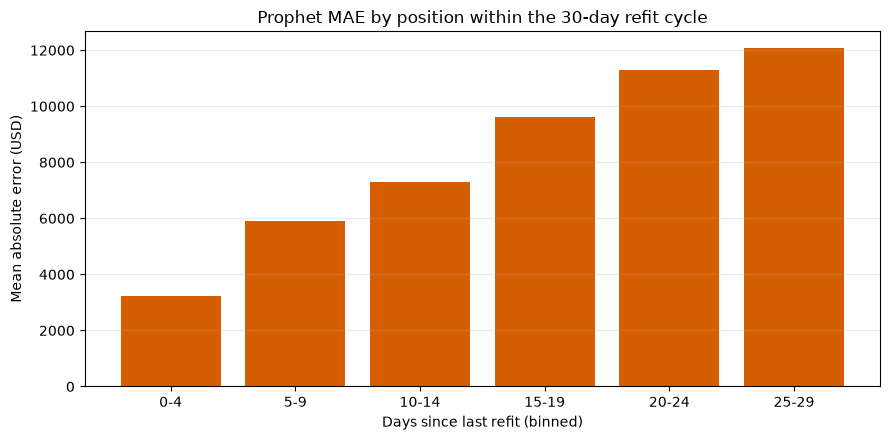

In [13]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(refit_cycle_mae.index.astype(str), refit_cycle_mae['MAE'], color='#D55E00')
ax.set(title='Prophet MAE by position within the 30-day refit cycle',
       xlabel='Days since last refit (binned)', ylabel='Mean absolute error (USD)')
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()
plt.show()

MAE rises sharply and close to monotonically across the cycle: from approximately \$3,212 in days 0-4 after a refit to approximately \$12,070 in days 25-29, roughly a 3.8x increase. This is direct evidence consistent with the staleness hypothesis -- forecast accuracy visibly degrades as the fitted model gets further from its most recent refit, rather than staying flat across the cycle. This does not, by itself, prove refit frequency is the *only* driver of Prophet's overall weak performance (Section 4.2), but it does support that within-cycle staleness is a real, measurable contributor.

# 5. Prophet Key Findings

- Prophet performs substantially worse than the classical rolling-one-step systems in Notebook 02: MAE is approximately 535% higher and RMSE approximately 482% higher than Naive (Section 4.2).
- The magnitude of the performance gap is large, not a marginal ranking difference -- Prophet is not "slightly behind" the classical floor, it is an order of magnitude worse on both MAE and RMSE.
- Prophet's periodic update schedule differs materially from the daily-updated classical systems (Section 3.1): it can operate on information up to 29 days older than same-day comparators.
- The refit-cycle diagnostic (Section 4.5) shows MAE increasing markedly across the 30-day cycle (roughly 3.8x from the first to the last bin), supporting -- though not by itself proving as the sole cause -- that staleness within the cycle contributes visibly to forecast error.
- Prophet remains informative as a protocol/update-frequency comparator even though it is not competitive on point accuracy: it demonstrates concretely how much an infrequently-updated system can degrade relative to daily-updated ones on a fast-moving series like Bitcoin.

It would not be justified to state "Prophet fails because it only refits every 30 days" as a complete causal explanation -- the refit-cycle pattern is consistent with that hypothesis, but Prophet's overall error is also shaped by its configuration (Section 3.2) and its own trend/changepoint modelling of a non-stationary price series (Notebook 01), which the cycle diagnostic alone does not isolate.

# 6. Prophet Limitations

- Prophet is refitted every 30 forecast dates rather than daily.
- Its effective fitted information can therefore be up to 29 days older than that of systems updated every day.
- This creates an operational **protocol/update-frequency asymmetry** relative to the daily-updated classical systems in Notebook 02 -- the comparison in Section 4.2 is informative but not a like-for-like update-schedule comparison.
- The model is still past-only and leakage-free (Section 3.1), but not operationally identical to daily-updated models.
- Prophet hyperparameters were not comprehensively tuned: the configuration in Section 3.2 reflects explicit choices plus framework defaults, not a documented search.
- Exact bit-level deterministic refitting has not been independently verified (Section 3.3).
- Evidence covers one Bitcoin asset (BTC/USD) and one frozen final test period (1,061 days, 2023-08-12 to 2026-07-07).

# 7. Deferred and Unavailable Models Registry

## 7.1 Scope Transparency

> This registry records model families considered during project development but not included in the authoritative empirical comparison. It documents evaluation scope and implementation constraints; it is not a performance table.

No performance rank is assigned to any model below. Unavailable does not mean poor. Deferred does not mean failed. The final model set evaluated in this project is intentionally non-exhaustive.

## 7.2 Model Registry

Evidence sources (read-only): this repository's Git history for the foundation-model compatibility investigation (`3b856a4`, `501601c`) and the deferred-NeuralForecast-scope investigation (`365daeb`), plus a read-only check of currently installed packages in this project's `.venv`.

In [14]:
deferred_registry = pd.DataFrame([
    {
        'Model / Family': 'Moirai / Uni2TS', 'Category': 'Foundation model', 'Status': 'UNAVAILABLE / COMPATIBILITY-BLOCKED',
        'Reason': 'uni2ts package not installed; official Uni2TS project metadata pins torch>=2.1,<2.5, while this project uses torch 2.12.1 (verified still current in this .venv)',
        'Empirical Forecast Artifact?': 'No', 'Included in Final Ranking?': 'No', 'Planned Future Work?': 'Yes (README: compatible Python 3.12 evaluation)',
    },
    {
        'Model / Family': 'PatchTST', 'Category': 'Supervised Transformer architecture (via NeuralForecast; not a zero-shot foundation model)', 'Status': 'NOT EXECUTED / COMPATIBILITY-BLOCKED',
        'Reason': 'neuralforecast>=3.1.8 requires pytorch-lightning<2.6.0, incompatible with the project\'s pinned lightning; neuralforecast==3.1.7 is lightning-compatible but requires ray[train,tune], unavailable for Windows/Python 3.13 at generation time',
        'Empirical Forecast Artifact?': 'No', 'Included in Final Ranking?': 'No', 'Planned Future Work?': 'Yes (README: compatible Python 3.12 evaluation)',
    },
    {
        'Model / Family': 'iTransformer', 'Category': 'Supervised Transformer architecture (via NeuralForecast; not a zero-shot foundation model)', 'Status': 'NOT EXECUTED / COMPATIBILITY-BLOCKED',
        'Reason': 'Same NeuralForecast dependency conflict documented for PatchTST (accessed via the same package)',
        'Empirical Forecast Artifact?': 'No', 'Included in Final Ranking?': 'No', 'Planned Future Work?': 'Yes (README: compatible Python 3.12 evaluation)',
    },
    {
        'Model / Family': 'Informer', 'Category': 'Deep forecasting framework', 'Status': 'NOT EXECUTED',
        'Reason': 'No documented compatibility investigation found in this repository\'s history; listed as a considered model family but never technically assessed',
        'Empirical Forecast Artifact?': 'No', 'Included in Final Ranking?': 'No', 'Planned Future Work?': 'Not mentioned in README Future Work',
    },
    {
        'Model / Family': 'Autoformer', 'Category': 'Deep forecasting framework', 'Status': 'NOT EXECUTED',
        'Reason': 'No documented compatibility investigation found in this repository\'s history; listed as a considered model family but never technically assessed',
        'Empirical Forecast Artifact?': 'No', 'Included in Final Ranking?': 'No', 'Planned Future Work?': 'Not mentioned in README Future Work',
    },
]).set_index('Model / Family')
deferred_registry

,Category,Status,Reason,Empirical Forecast Artifact?,Included in Final Ranking?,Planned Future Work?
Model / Family,,,,,,
Moirai / Uni2TS,Foundation model,UNAVAILABLE / COMPATIBILITY-BLOCKED,uni2ts package not installed; official Uni2TS ...,No,No,Yes (README: compatible Python 3.12 evaluation)
PatchTST,Supervised Transformer architecture (via Neura...,NOT EXECUTED / COMPATIBILITY-BLOCKED,neuralforecast>=3.1.8 requires pytorch-lightni...,No,No,Yes (README: compatible Python 3.12 evaluation)
iTransformer,Supervised Transformer architecture (via Neura...,NOT EXECUTED / COMPATIBILITY-BLOCKED,Same NeuralForecast dependency conflict docume...,No,No,Yes (README: compatible Python 3.12 evaluation)
Informer,Deep forecasting framework,NOT EXECUTED,No documented compatibility investigation foun...,No,No,Not mentioned in README Future Work
Autoformer,Deep forecasting framework,NOT EXECUTED,No documented compatibility investigation foun...,No,No,Not mentioned in README Future Work


A read-only check of this project's `.venv` (no model executed, no data touched) found `neuralforecast` is actually installed, but importing it currently raises `AttributeError: module 'pytorch_lightning.utilities' has no attribute 'distributed'` -- a live, freshly-reproduced confirmation that the PatchTST/iTransformer path remains blocked today, though the precise failure signature has shifted since the historically documented reason (consistent with ongoing dependency drift between then and now, not a contradiction of it). `uni2ts` is confirmed **not installed**, and the installed `torch` version (2.12.1) still violates Uni2TS's `torch<2.5` pin, matching the historical Moirai finding exactly.

# 8. Notebook-Level Key Findings

- Prophet is the weakest fully evaluated Bitcoin model in the current project on point accuracy (Section 4.1-4.2) -- no other model with a frozen authoritative forecast artifact has a comparably large gap from Naive.
- Its periodic-refit protocol is intentionally documented in detail (Section 3.1, Section 4.5) because update frequency is itself part of a forecasting system's real-world behaviour, not an incidental implementation detail.
- The deferred-model registry (Section 7) shows that the evaluated model roster in this project is deliberate but not exhaustive: several model families were considered and specifically investigated (Moirai, PatchTST, iTransformer) while others were named but never technically assessed (Informer, Autoformer).
- Therefore, this project's trustworthiness conclusions apply only to the actually executed model set (Naive, MA7, SES, additive-trend smoothing, ARIMA, Prophet, PE-LSTM, PE-Transformer, Chronos-Bolt-Tiny, TimesFM) and must not be read as a universal ranking of all modern forecasting architectures.

# 9. Next Notebook

Next: `06_Bitcoin_Foundation_Models.ipynb`

Notebook 06 evaluates the project's zero-shot time-series foundation models -- Chronos-Bolt-Tiny and TimesFM -- against the benchmark evidence established in the earlier Bitcoin notebooks.